# MEEP Mode Solver — Rib Waveguide

Fundamental TE mode of a silicon rib waveguide: ``n_eff`` + 2D (Y, Z) field profile.

**Cross-section:** SiO2 box / Si slab 70 nm / Si rib 150 nm (total 220 nm).
Lateral confinement via effective-index contrast.

### Imports

In [1]:
import gdsfactory as gf
import matplotlib.pyplot as plt
import numpy as np

import gsim.meep as gm
from gsim.common.stack.extractor import Layer, LayerStack

plt.close()

gf.gpdk.PDK.activate()

### Build the GDS component

In [2]:
SLAB_WIDTH = 3.0  # um
RIB_WIDTH = 0.5  # um
LENGTH = 10.0  # um

c = gf.Component()

# Si rib layer (layer 2) - narrow ridge on top
c.add_polygon(
    [
        (-LENGTH / 2, -RIB_WIDTH / 2),
        (LENGTH / 2, -RIB_WIDTH / 2),
        (LENGTH / 2, RIB_WIDTH / 2),
        (-LENGTH / 2, RIB_WIDTH / 2),
    ],
    layer=(2, 0),
)

# Ports at both ends
c.add_port(
    name="o1", center=(-LENGTH / 2, 0), width=RIB_WIDTH, orientation=180, layer=(1, 0)
)
c.add_port(
    name="o2", center=(LENGTH / 2, 0), width=RIB_WIDTH, orientation=0, layer=(1, 0)
)

print(f"Component: {c.name}")
print(f"  Ports:  {[p.name for p in c.ports]}")
print(f"  Layers: {list(c.layers)}")

Component: Unnamed_0
  Ports:  ['o1', 'o2']
  Layers: [(2, 0)]


### Layer stack

In [3]:
layers = {
    "ox": Layer(
        name="box",
        gds_layer=(0, 0),
        zmin=-1,
        zmax=0.0,
        thickness=1.0,
        material="sio2",
        layer_type="dielectric",
    ),
    "slab": Layer(
        name="slab",
        gds_layer=(1, 0),
        zmin=0.0,
        zmax=0.07,
        thickness=0.07,
        material="si",
        layer_type="dielectric",
    ),
    "rib": Layer(
        name="rib",
        gds_layer=(2, 0),
        zmin=0.07,
        zmax=0.22,
        thickness=0.15,
        material="si",
        layer_type="dielectric",
    ),
}
stack = LayerStack(layers=layers)

print("Layer stack:")
for name, l in stack.layers.items():
    print(
        f"  {name:6s}  z=[{l.zmin:+.3f}, {l.zmax:+.3f}]  t={l.thickness:.3f}  material={l.material}"
    )

Layer stack:
  ox      z=[-1.000, +0.000]  t=1.000  material=sio2
  slab    z=[+0.000, +0.070]  t=0.070  material=si
  rib     z=[+0.070, +0.220]  t=0.150  material=si


### Solve

In [4]:
WAVELENGTH = 1.55  # um
RESOLUTION = 64
PML_THICKNESS = 1 * WAVELENGTH


sim = gm.Simulation(
    geometry=gm.Geometry(component=c, stack=stack),
    domain=gm.Domain(
        pml=PML_THICKNESS,
        margin_z=(0.0, 0.5),
    ),
)
N_BANDS = 4

sim.mode_solver.wavelengths = [WAVELENGTH]
sim.mode_solver.first(N_BANDS).at_port("o1")
sim.mode_solver.y_span = SLAB_WIDTH
sim.mode_solver.n_field_y = 300
sim.mode_solver.n_field_z = 300

sweep = sim.solve_modes()

# n_eff for every band found at this wavelength
modes = sorted(sweep.at(WAVELENGTH).results, key=lambda r: r.band_num)
print(f"Solved {len(modes)} mode(s) at lambda={WAVELENGTH:.2f} µm:")
for m in modes:
    print(f"  band {m.band_num}: n_eff = {m.n_eff:.6f}  (parity={m.parity})")

# fundamental mode used for the plots below
mode = sweep.at(WAVELENGTH).band(1)

print(f"\nn_eff    = {mode.n_eff:.6f}")
print(f"n_group  = {mode.n_group}")
print(f"kdom     = {[f'{k:.6f}' for k in mode.kdom]}")
print(f"band     = {mode.band_num}, parity = {mode.parity}")
print(f"fields   = {list(mode.fields.keys())}")
for comp, arr in mode.fields.items():
    print(f"  {comp}: shape={arr.shape}  |max|={np.abs(arr).max():.6f}")

  meep-de12d79d  completed  3m 07s


Extracting results.tar.gz...
Downloaded 28 files to /Users/vahid/doplaydo/gsim/sim-data-meep-de12d79d
Solved 4 mode(s) at lambda=1.55 µm:
  band 1: n_eff = 2.395249  (parity=NO_PARITY)
  band 2: n_eff = 1.791086  (parity=NO_PARITY)
  band 3: n_eff = 1.645533  (parity=NO_PARITY)
  band 4: n_eff = 1.652899  (parity=NO_PARITY)

n_eff    = 2.395249
n_group  = 3.947109597503744
kdom     = ['1.545322', '-0.000000', '0.000000']
band     = 1, parity = NO_PARITY
fields   = ['Ex', 'Ey', 'Ez', 'Hx', 'Hy', 'Hz']
  Ex: shape=(300, 300)  |max|=2.319336
  Ey: shape=(300, 300)  |max|=4.563733
  Ez: shape=(300, 300)  |max|=1.139852
  Hx: shape=(300, 300)  |max|=6.975301
  Hy: shape=(300, 300)  |max|=2.883016
  Hz: shape=(300, 300)  |max|=14.500522


### Index profile

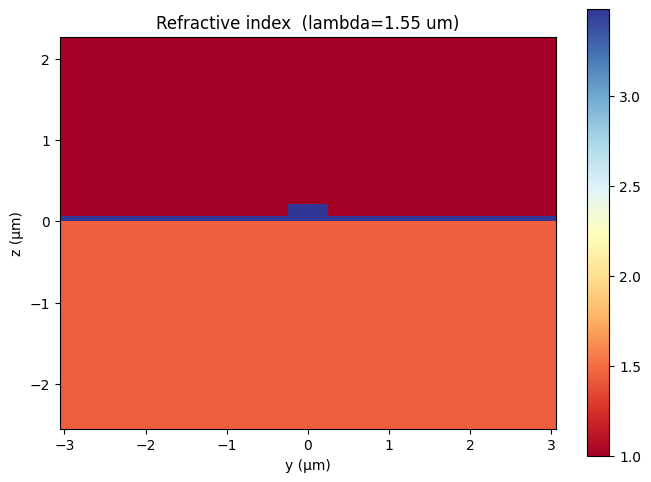

(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'Refractive index  (lambda=1.55 um)'}, xlabel='y (µm)', ylabel='z (µm)'>)

In [5]:
mode.plot_index(show=True)

### Mode profile (interactive)

``|field|`` maps for every component with zoom / pan / hover. Axes use equal
aspect so the cross-section is physically proportioned.

In [6]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

comps = [c for c in ("Ex", "Ey", "Ez", "Hx", "Hy", "Hz") if c in mode.fields]

# Crop to the (small, centered) mode region and downsample so the embedded
# heatmaps stay light-weight for the docs while remaining smooth on zoom.
energy = sum(np.abs(mode.fields[c]) ** 2 for c in comps)
thr = 0.02 * energy.max()
yi = np.where(energy.max(axis=0) > thr)[0]
zi = np.where(energy.max(axis=1) > thr)[0]
dy, dz = mode.y_grid[1] - mode.y_grid[0], mode.z_grid[1] - mode.z_grid[0]
pad = 0.4  # µm margin around the mode
y0, y1 = (
    max(yi.min() - int(pad / dy), 0),
    min(yi.max() + int(pad / dy) + 1, mode.y_grid.size),
)
z0, z1 = (
    max(zi.min() - int(pad / dz), 0),
    min(zi.max() + int(pad / dz) + 1, mode.z_grid.size),
)
max_pts = 140  # per axis
sy, sz = max(1, (y1 - y0) // max_pts), max(1, (z1 - z0) // max_pts)
y_sub, z_sub = mode.y_grid[y0:y1:sy], mode.z_grid[z0:z1:sz]

fig = make_subplots(
    rows=2,
    cols=3,
    subplot_titles=[f"|{c}|" for c in comps],
    horizontal_spacing=0.08,
    vertical_spacing=0.12,
)

for i, comp in enumerate(comps):
    row, col = i // 3 + 1, i % 3 + 1
    # Mode fields are in arbitrary units; normalize each panel to its own max
    # and quantize to 8-bit (0..255). Plotly embeds arrays as binary, so this
    # keeps the notebook small while staying visually identical.
    panel = np.abs(mode.fields[comp][z0:z1:sz, y0:y1:sy])
    panel = np.round(panel / panel.max() * 255).astype(np.uint8)
    fig.add_trace(
        go.Heatmap(
            x=y_sub,
            y=z_sub,
            z=panel,
            colorscale="Inferno",
            showscale=False,
            zmin=0,
            zmax=255,
            hovertemplate=(
                "y=%{x:.3f} µm<br>z=%{y:.3f} µm<br>"
                "|" + comp + "| (rel.)=%{z}<extra></extra>"
            ),
        ),
        row=row,
        col=col,
    )
    x_anchor = "x" if i == 0 else f"x{i + 1}"
    fig.update_xaxes(title_text="y (µm)", row=row, col=col)
    fig.update_yaxes(
        title_text="z (µm)", scaleanchor=x_anchor, scaleratio=1, row=row, col=col
    )

fig.update_layout(
    height=750,
    width=1050,
    title_text=(
        f"Rib waveguide fundamental TE mode  "
        f"(lambda={WAVELENGTH:.2f} µm, n_eff={mode.n_eff:.4f})"
    ),
)
fig.show()